In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set() # for plot styling

/tmp/ipython-input-955/2315185086.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:,0],X[:,1],s=50,cmap='viridis')


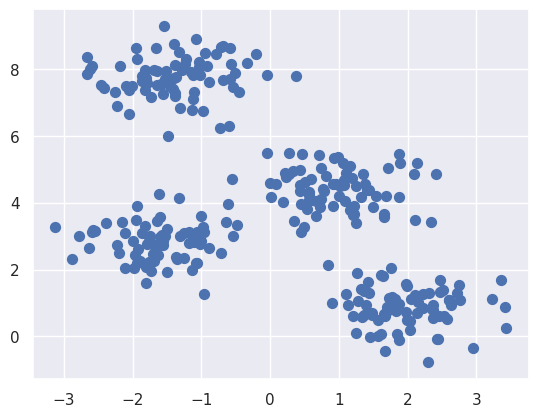

In [7]:
from sklearn.datasets import make_blobs
X,y_true = make_blobs(n_samples=300,centers=4 ,
                      cluster_std=0.60,random_state=0)
plt.scatter(X[:,0],X[:,1],s=50)
plt.show()

In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

In [10]:
y_kmeans

array([3, 0, 1, 0, 3, 3, 2, 1, 0, 0, 2, 0, 1, 0, 3, 1, 1, 3, 2, 2, 3, 3,
       1, 2, 2, 1, 3, 1, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 3, 1, 2, 1, 1,
       2, 2, 0, 2, 0, 3, 2, 3, 0, 3, 3, 2, 0, 2, 0, 3, 0, 1, 0, 2, 2, 2,
       0, 3, 0, 2, 1, 2, 0, 2, 2, 0, 2, 1, 3, 0, 3, 1, 3, 3, 0, 1, 3, 1,
       0, 0, 1, 3, 0, 2, 2, 1, 3, 3, 1, 2, 0, 3, 0, 3, 1, 3, 3, 1, 0, 1,
       2, 2, 3, 0, 3, 1, 0, 3, 3, 1, 2, 3, 2, 3, 3, 3, 3, 2, 3, 2, 0, 2,
       2, 3, 0, 2, 2, 0, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0, 1,
       3, 2, 0, 2, 3, 1, 0, 1, 1, 3, 1, 2, 2, 1, 3, 1, 1, 0, 3, 1, 2, 0,
       3, 3, 1, 2, 3, 1, 2, 2, 1, 1, 1, 1, 3, 0, 1, 2, 1, 1, 2, 2, 2, 1,
       2, 0, 1, 2, 3, 2, 1, 0, 2, 0, 1, 0, 1, 2, 1, 1, 0, 2, 2, 3, 3, 1,
       0, 3, 3, 2, 3, 2, 1, 0, 0, 1, 1, 0, 1, 3, 2, 1, 3, 2, 0, 2, 3, 1,
       3, 0, 0, 0, 0, 2, 2, 0, 1, 2, 3, 1, 2, 2, 2, 3, 3, 0, 1, 1, 2, 3,
       0, 2, 1, 0, 1, 3, 3, 2, 2, 1, 3, 3, 3, 1, 0, 0, 3, 3, 1, 3, 3, 3,
       0, 2, 0, 1, 3, 3, 0, 0, 0, 3, 3, 1, 0, 2], d

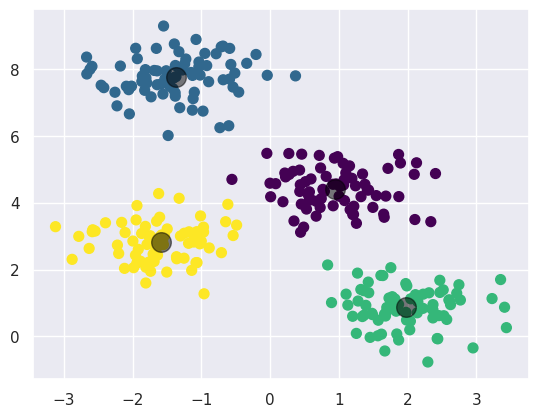

In [11]:
from sklearn.metrics import pairwise_distances_argmin
def find_clusters(X,n_clusters,rseed = 2):
   #1.Randomly Choose Clusters
  rng = np.random.RandomState(rseed)
  i=rng.permutation(X.shape[0])[:n_clusters]
  centers = X[i]

  while True:
    #2 a.Assign Labels bases on closest center
    labels = pairwise_distances_argmin(X,centers)
    #2 b.Find new centers from means of points
    new_centers = np.array([X[labels==i].mean(0)
                             for i in range(n_clusters)])

    #2 c. Check the Convergence
    if np.all(centers==new_centers):
      break
    centers = new_centers
  return centers , labels

centers ,labels = find_clusters(X,4)
plt.scatter(X[:,0],X[:,1],c=labels,s=50,cmap='viridis')
plt.scatter(centers[:,0],centers[:,1],c='black',s=200,alpha=0.5)
plt.show()

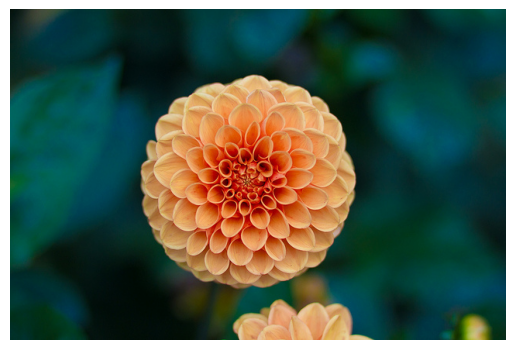

In [14]:
# K_Means For Color Compression
from sklearn.datasets import load_sample_images
dataset = load_sample_images()
flower = dataset.images[1]
plt.imshow(flower)
plt.axis('off')
plt.show()


In [15]:
flower.shape

(427, 640, 3)

array([[[ 2, 19, 13],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 1, 77, 64],
        [ 0, 76, 64],
        [ 0, 75, 63]],

       [[ 1, 18, 12],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 0, 76, 64],
        [ 1, 74, 65],
        [ 1, 74, 65]],

       [[ 2, 17, 12],
        [ 6, 19, 12],
        [ 7, 20, 13],
        ...,
        [ 1, 74, 65],
        [ 1, 74, 67],
        [ 1, 74, 67]],

       ...,

       [[ 0, 46, 40],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 5, 44, 26],
        [ 6, 43, 26],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 6, 45, 27],
        [ 7, 44, 27],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 0, 46, 36],
        ...,
        [ 7, 46, 28],
        [ 8, 45, 28],
        [ 9, 43, 27]]], dtype=uint8)
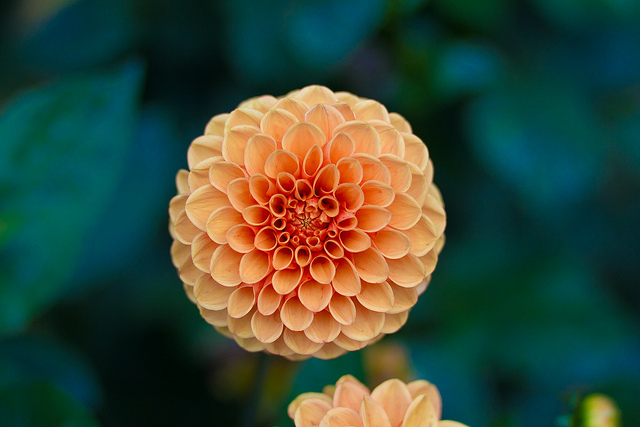

In [18]:
flower

In [19]:
data = flower / 255.0 # use 0 ... 1 scale
data = data.reshape(427*640,3) # convert 3D into 2D
data.shape

(273280, 3)

In [20]:
data

array([[0.00784314, 0.0745098 , 0.05098039],
       [0.01176471, 0.07058824, 0.05098039],
       [0.02745098, 0.07843137, 0.05098039],
       ...,
       [0.02745098, 0.18039216, 0.10980392],
       [0.03137255, 0.17647059, 0.10980392],
       [0.03529412, 0.16862745, 0.10588235]])

In [31]:
def plot_pixels(data,title,colors=None , N=1000):
  if colors is None :
    colors = data

  # choose a random subset

  rng = np.random.RandomState(0)
  i = rng.permutation(data.shape[0])[:N]
  colors = colors[i]
  R,G,B = data[i].T

  fig,ax = plt.subplots(1,2,figsize=(16,6))
  ax[0].scatter(R,G,color=colors,marker='.')
  ax[0].set(xlabel='Red',ylabel='Green',xlim=(0,1),ylim=(0,1))

  ax[1].scatter(R,B,color=colors,marker='.')
  ax[1].set(xlabel='Red',ylabel='Blue',xlim=(0,1),ylim=(0,1))

  fig.suptitle(title,size=20)



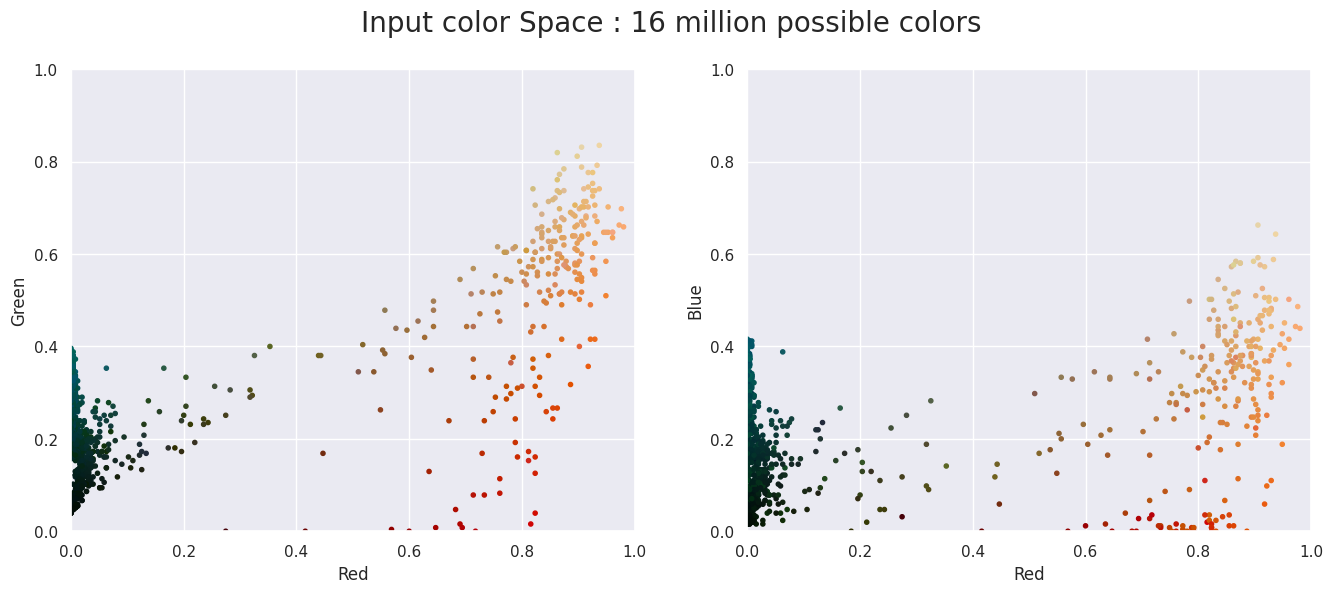

In [32]:
plot_pixels(data,title = 'Input color Space : 16 million possible colors')


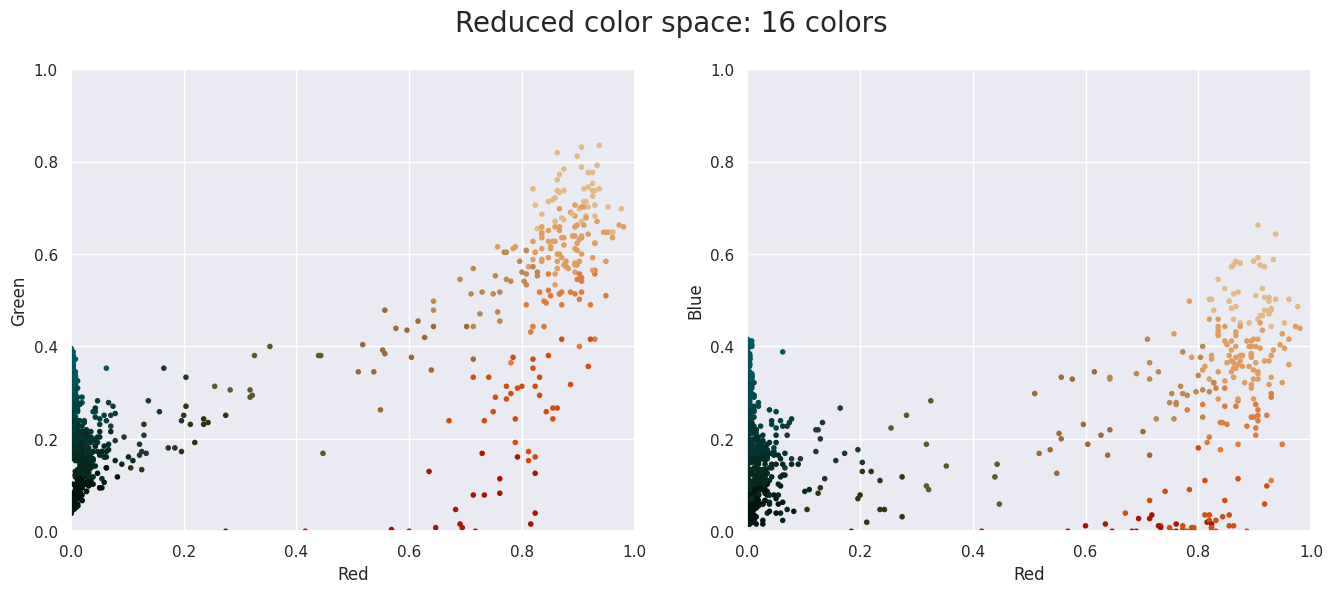

In [33]:
import warnings ; warnings.simplefilter('ignore')  # fix numpy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data,colors= new_colors, title="Reduced color space: 16 colors")
plt.show()

Text(0.5, 1.0, '16 - color Image')

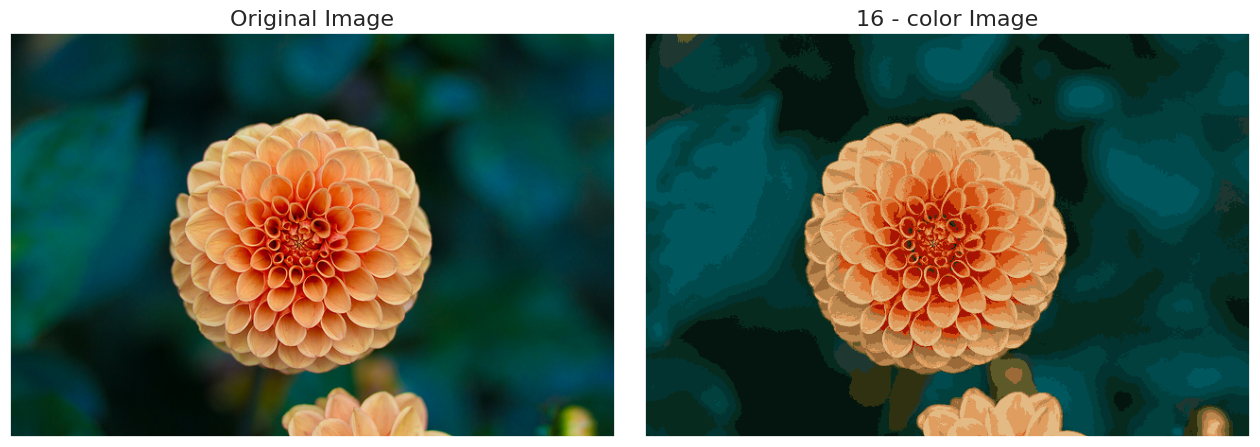

In [34]:
flower_recolored = new_colors.reshape(flower.shape)
fig,ax = plt.subplots(1,2,figsize=(16,6),subplot_kw=dict(xticks=[] , yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image' , size =16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16 - color Image' , size = 16)